# MultVAE Hyperparameter Tuning

## 1. Setup

### 1.1. Imports

In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import sys
sys.path.insert(0, '..')

import json
import pickle
import time
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

from src.data.loader import load_ratings
from src.data.splitter import split_temporal
from src.data.adapter import DataAdapter
from src.models.multvae import MultVAE
from src.evaluation.metrics import compute_ranking_metrics

### 1.2 Load and split data

In [3]:
ratings = load_ratings()

train_df, val_df, test_df = split_temporal(
    ratings,
    train_ratio=0.7,
    validation_ratio=0.15,
    test_ratio=0.15,
)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

# Convert to IMPLICIT feedback (rating >= 4 = positive interaction)
adapter = DataAdapter()
train_data = adapter.to_implicit(train_df, threshold=4.0)

print(f"Positive interactions in training: {train_data.X_ui.nnz:,}")

Loaded 1000209 ratings from /content/ucu-recsys/data/ml-1m/ratings.dat
Train: 700,118 | Val: 150,081 | Test: 150,010
Positive interactions in training: 416,338


## 2. Tuning

### 2.1 Grid search parameters

In [4]:
param_grid = {
    'intermediate_dim': [100, 200, 400],
    'latent_dim': [50, 70, 100],
    'n_epochs': [50, 100],
    'beta': [0.5, 1.0],
}

# Generate all combinations
param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(product(*param_values))

print(f"Total combinations to try: {len(all_combinations)}")

Total combinations to try: 36


### 2.2 Grid search

In [5]:
results = []

# Only evaluate against positive validation interactions
val_positive = val_df[val_df['rating'] >= 4]
all_val_users = val_positive['user_id'].unique()

# Sample eval users for speed — recommend_for_eval is the bottleneck
np.random.seed(42)
n_eval_users = min(1000, len(all_val_users))
val_users = np.random.choice(all_val_users, size=n_eval_users, replace=False)
val_positive_sampled = val_positive[val_positive['user_id'].isin(val_users)]

print(f"Evaluating on {len(val_positive_sampled):,} positive interactions from {len(val_users):,} users (sampled from {len(all_val_users):,})")

for combo in tqdm(all_combinations, desc="Grid Search"):
    params = dict(zip(param_names, combo))

    model = MultVAE(
        intermediate_dim=params['intermediate_dim'],
        latent_dim=params['latent_dim'],
        n_epochs=params['n_epochs'],
        beta=params['beta'],
        batch_size=512,
        seed=42,
    )

    start_time = time.time()
    model.fit(train_data)
    train_time = time.time() - start_time

    # Generate recommendations for ranking eval
    recommendations = model.recommend_for_eval(val_users, k=10)
    val_ranking = compute_ranking_metrics(val_positive_sampled, recommendations, top_k=10)

    result = {
        **params,
        'val_ndcg': val_ranking['ndcg'],
        'val_recall': val_ranking['recall'],
        'train_time_sec': train_time,
    }
    results.append(result)

    print(f"{params} -> NDCG: {val_ranking['ndcg']:.4f} ({train_time:.1f}s)")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('val_ndcg', ascending=False)
results_df.head(10)

Evaluating on 13,294 positive interactions from 1,000 users (sampled from 5,927)


Grid Search:   0%|          | 0/36 [00:00<?, ?it/s]

Epoch 1/50
11/11 [==============================] - 5s 32ms/step - loss: 560.6703 - val_loss: 603.5038
Epoch 2/50
11/11 [==============================] - 0s 11ms/step - loss: 546.3293 - val_loss: 568.1887
Epoch 3/50
11/11 [==============================] - 0s 10ms/step - loss: 512.9772 - val_loss: 546.5073
Epoch 4/50
11/11 [==============================] - 0s 10ms/step - loss: 502.4595 - val_loss: 540.4671
Epoch 5/50
11/11 [==============================] - 0s 11ms/step - loss: 498.4076 - val_loss: 538.3722
Epoch 6/50
11/11 [==============================] - 0s 10ms/step - loss: 496.2724 - val_loss: 536.4047
Epoch 7/50
11/11 [==============================] - 0s 11ms/step - loss: 494.7104 - val_loss: 535.0464
Epoch 8/50
11/11 [==============================] - 0s 11ms/step - loss: 494.1970 - val_loss: 535.1226
Epoch 9/50
11/11 [==============================] - 0s 11ms/step - loss: 493.5473 - val_loss: 534.7002
Epoch 10/50
11/11 [==============================] - 0s 11ms/step - loss:

Grid Search:   3%|▎         | 1/36 [01:09<40:45, 69.88s/it]

{'intermediate_dim': 100, 'latent_dim': 50, 'n_epochs': 50, 'beta': 0.5} -> NDCG: 0.0808 (12.4s)
Epoch 1/50
11/11 [==============================] - 3s 63ms/step - loss: 560.8589 - val_loss: 604.4769
Epoch 2/50
11/11 [==============================] - 0s 11ms/step - loss: 549.2780 - val_loss: 574.5698
Epoch 3/50
11/11 [==============================] - 0s 11ms/step - loss: 519.0360 - val_loss: 549.8019
Epoch 4/50
11/11 [==============================] - 0s 10ms/step - loss: 504.4805 - val_loss: 542.3010
Epoch 5/50
11/11 [==============================] - 0s 11ms/step - loss: 499.8889 - val_loss: 539.1270
Epoch 6/50
11/11 [==============================] - 0s 11ms/step - loss: 497.4390 - val_loss: 537.9694
Epoch 7/50
11/11 [==============================] - 0s 11ms/step - loss: 496.0512 - val_loss: 537.1420
Epoch 8/50
11/11 [==============================] - 0s 11ms/step - loss: 496.1331 - val_loss: 537.4622
Epoch 9/50
11/11 [==============================] - 0s 11ms/step - loss: 495.56

...

Grid Search:  97%|█████████▋| 35/36 [40:35<01:09, 69.56s/it]

{'intermediate_dim': 400, 'latent_dim': 100, 'n_epochs': 100, 'beta': 0.5} -> NDCG: 0.0929 (15.1s)
Epoch 1/100
11/11 [==============================] - 2s 28ms/step - loss: 559.7728 - val_loss: 582.1880
Epoch 2/100
11/11 [==============================] - 0s 11ms/step - loss: 520.7707 - val_loss: 546.9913
Epoch 3/100
11/11 [==============================] - 0s 11ms/step - loss: 505.1270 - val_loss: 541.7637
Epoch 4/100
11/11 [==============================] - 0s 11ms/step - loss: 499.5717 - val_loss: 539.5182
Epoch 5/100
11/11 [==============================] - 0s 11ms/step - loss: 497.9092 - val_loss: 537.1845
Epoch 6/100
11/11 [==============================] - 0s 11ms/step - loss: 496.8491 - val_loss: 535.7630
Epoch 7/100
11/11 [==============================] - 0s 11ms/step - loss: 493.7382 - val_loss: 531.4759
Epoch 8/100
11/11 [==============================] - 0s 10ms/step - loss: 490.5200 - val_loss: 528.7537
Epoch 9/100
11/11 [==============================] - 0s 10ms/step - l

Grid Search: 100%|██████████| 36/36 [41:46<00:00, 69.62s/it]

{'intermediate_dim': 400, 'latent_dim': 100, 'n_epochs': 100, 'beta': 1.0} -> NDCG: 0.0919 (14.4s)


,intermediate_dim,latent_dim,n_epochs,beta,val_ndcg,val_recall,train_time_sec
24,400,50,50,0.5,0.099374,0.084509,8.705627
26,400,50,100,0.5,0.097230,0.084357,14.788694
32,400,100,50,0.5,0.096643,0.075108,8.865557
14,200,50,100,0.5,0.096626,0.078856,14.407746
18,200,70,100,0.5,0.095019,0.075481,14.278148
27,400,50,100,1.0,0.093999,0.076500,14.683626
2,100,50,100,0.5,0.093796,0.074554,14.279862
34,400,100,100,0.5,0.092942,0.083536,15.135379
31,400,70,100,1.0,0.092849,0.075557,14.595613
16,200,70,50,0.5,0.092658,0.077348,8.777526


In [6]:
# Best parameters (by NDCG)
best_row = results_df.iloc[0]
best_params = {
    'intermediate_dim': int(best_row['intermediate_dim']),
    'latent_dim': int(best_row['latent_dim']),
    'n_epochs': int(best_row['n_epochs']),
    'beta': float(best_row['beta']),
}

print("Best parameters:")
print(json.dumps(best_params, indent=2))
print(f"\nValidation NDCG@10: {best_row['val_ndcg']:.4f}")
print(f"Validation Recall@10: {best_row['val_recall']:.4f}")

Best parameters:
{
  "intermediate_dim": 400,
  "latent_dim": 50,
  "n_epochs": 50,
  "beta": 0.5
}

Validation NDCG@10: 0.0994
Validation Recall@10: 0.0845


## 3. Retrain best model

### 3.1 Retrain best model on train+val, evaluate on test

In [7]:
# Combine train and validation for final model
train_val_df = pd.concat([train_df, val_df], ignore_index=True)
train_val_data = adapter.to_implicit(train_val_df, threshold=4.0)

# Train final model
final_model = MultVAE(**best_params, seed=42)
final_model.fit(train_val_data)

# Ranking eval (NDCG, etc.) - only on positive test interactions
test_positive = test_df[test_df['rating'] >= 4]
test_users = test_positive['user_id'].unique()
recommendations = final_model.recommend_for_eval(test_users, k=10)
ranking_metrics = compute_ranking_metrics(test_positive, recommendations, top_k=10)

print(f"Test NDCG@10: {ranking_metrics['ndcg']:.4f}")
print(f"Test MAP@10: {ranking_metrics['map']:.4f}")
print(f"Test Precision@10: {ranking_metrics['precision']:.4f}")
print(f"Test Recall@10: {ranking_metrics['recall']:.4f}")

Epoch 1/50
55/55 [==============================] - 3s 8ms/step - loss: 620.4585 - val_loss: 643.7894
Epoch 2/50
55/55 [==============================] - 0s 5ms/step - loss: 589.9531 - val_loss: 630.8596
Epoch 3/50
55/55 [==============================] - 0s 5ms/step - loss: 582.0078 - val_loss: 623.2983
Epoch 4/50
55/55 [==============================] - 0s 5ms/step - loss: 574.9628 - val_loss: 617.3855
Epoch 5/50
55/55 [==============================] - 0s 5ms/step - loss: 569.0680 - val_loss: 612.0749
Epoch 6/50
55/55 [==============================] - 0s 5ms/step - loss: 565.4661 - val_loss: 610.2449
Epoch 7/50
55/55 [==============================] - 0s 5ms/step - loss: 563.6111 - val_loss: 608.9347
Epoch 8/50
55/55 [==============================] - 0s 5ms/step - loss: 561.9974 - val_loss: 607.2327
Epoch 9/50
55/55 [==============================] - 0s 5ms/step - loss: 560.3644 - val_loss: 605.2264
Epoch 10/50
55/55 [==============================] - 0s 5ms/step - loss: 558.9363 

### 3.2 Save best model and results

In [8]:
artifacts_dir = Path('../artifacts')
artifacts_dir.mkdir(exist_ok=True)

# Save parameters
params_to_save = {
    'best_params': best_params,
    'val_ndcg': float(best_row['val_ndcg']),
    'test_ranking_metrics': ranking_metrics,
}
with open(artifacts_dir / 'multvae_params.json', 'w') as f:
    json.dump(params_to_save, f, indent=2)
print(f"Parameters saved to {artifacts_dir / 'multvae_params.json'}")

# Save full results
results_df.to_csv(artifacts_dir / 'multvae_grid_search.csv', index=False)
print(f"Grid search results saved to {artifacts_dir / 'multvae_grid_search.csv'}")

Parameters saved to ../artifacts/multvae_params.json
Grid search results saved to ../artifacts/multvae_grid_search.csv


### 3.3 Visualize results

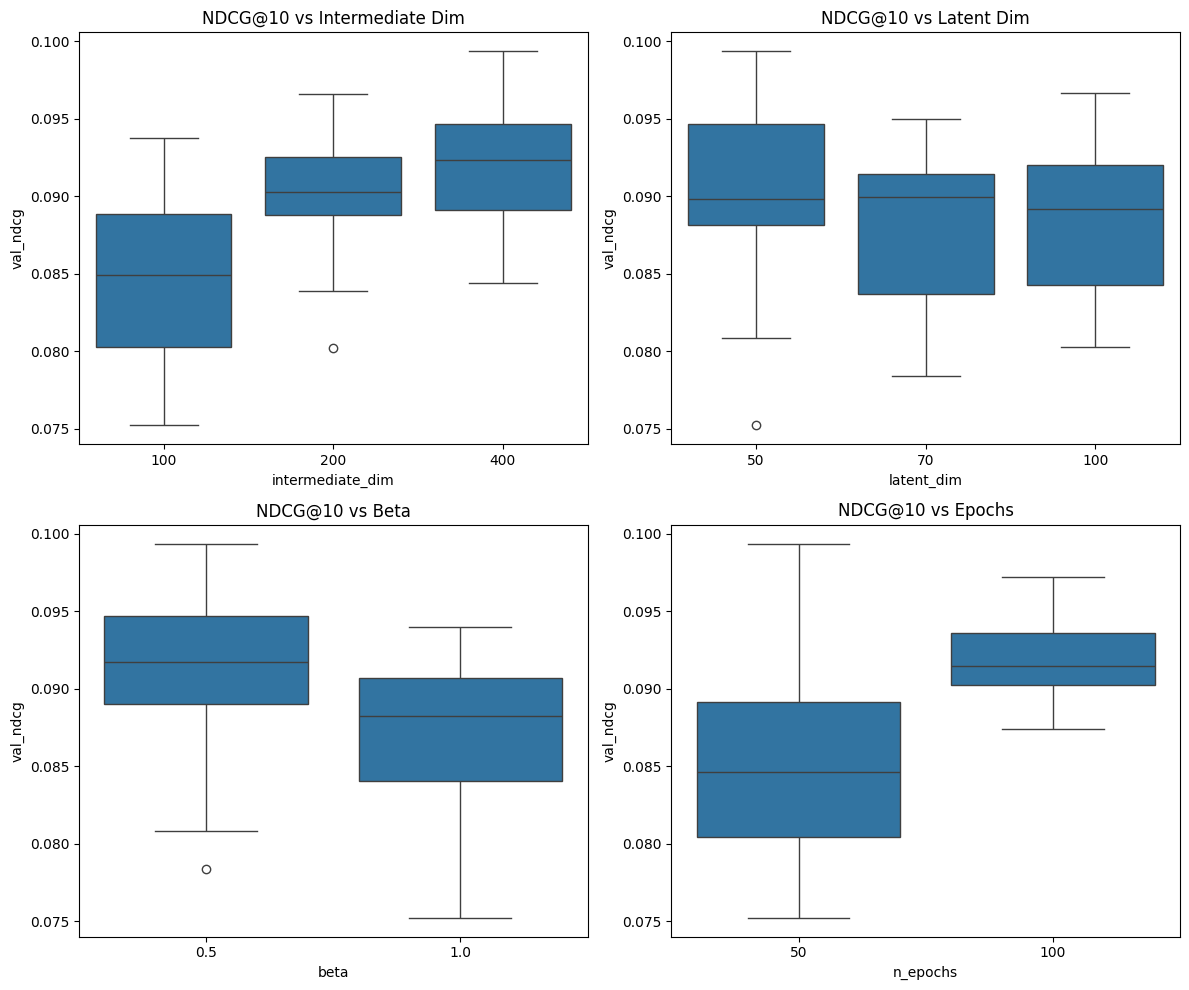

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# NDCG vs intermediate_dim
ax = axes[0, 0]
sns.boxplot(data=results_df, x='intermediate_dim', y='val_ndcg', ax=ax)
ax.set_title('NDCG@10 vs Intermediate Dim')

# NDCG vs latent_dim
ax = axes[0, 1]
sns.boxplot(data=results_df, x='latent_dim', y='val_ndcg', ax=ax)
ax.set_title('NDCG@10 vs Latent Dim')

# NDCG vs beta
ax = axes[1, 0]
sns.boxplot(data=results_df, x='beta', y='val_ndcg', ax=ax)
ax.set_title('NDCG@10 vs Beta')

# NDCG vs epochs
ax = axes[1, 1]
sns.boxplot(data=results_df, x='n_epochs', y='val_ndcg', ax=ax)
ax.set_title('NDCG@10 vs Epochs')

plt.tight_layout()
plt.savefig(artifacts_dir / 'multvae_tuning_plots.png', dpi=150)
plt.show()